<a href="https://colab.research.google.com/github/felizzi/nhanes-accel-cardiometabolic-benchmark/blob/main/nhanes_accel_SD4H_workshop_ICML_2026_orig.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =============================================================================
# CELL 1 — Run this first in Colab
# Mount Google Drive + upload data
# =============================================================================

from google.colab import drive, files as colab_files
drive.mount("/content/drive")

import os
os.makedirs("/content/drive/MyDrive/nhanes_results", exist_ok=True)
os.makedirs("/content/data", exist_ok=True)

print("Upload nhanes_analytic.csv when prompted...")
uploaded = colab_files.upload()
import shutil
shutil.move("nhanes_analytic.csv", "/content/data/nhanes_analytic.csv")
print("Data ready.")

Mounted at /content/drive
Upload nhanes_analytic.csv when prompted...


Saving nhanes_analytic.csv to nhanes_analytic.csv
Data ready.


In [ ]:
pip install tabpfn-client

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.3
    Uninstalling tqdm-4.67.3:
      Successfully uninstalled tqdm-4.67.3


In [ ]:
# =============================================================================
# CELL 2 — Install packages (PyTorch already installed in Colab)
# =============================================================================

import subprocess, sys
for pkg in ["xgboost", "tabpfn", "seaborn"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("Packages ready.")

from google.colab import userdata
import os

os.environ["TABPFN_TOKEN"] = userdata.get("TABPFN_TOKEN")
print("Token set:", os.environ["TABPFN_TOKEN"][:8] + "...")  # shows first 8 chars to confirm


Packages ready.
Token set: eyJhbGci...


In [ ]:
# =============================================================================
# CELL 3 — Full Analysis Pipeline
# =============================================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

SEED    = 42
OUT_DIR = "/content/drive/MyDrive/nhanes_results"
np.random.seed(SEED)
torch.manual_seed(SEED)
print("All imports OK.\n")

All imports OK.



In [ ]:
# ---------------------------------------------------------------------------
# FT-TRANSFORMER (pure PyTorch, no rtdl)
# ---------------------------------------------------------------------------

class NumEmb(nn.Module):
    def __init__(self, n, d):
        super().__init__()
        self.W = nn.Parameter(torch.empty(n, d)); nn.init.kaiming_uniform_(self.W)
        self.b = nn.Parameter(torch.zeros(n, d))
    def forward(self, x):
        return x.unsqueeze(-1) * self.W + self.b          # (B,n,d)

class CatEmb(nn.Module):
    def __init__(self, cards, d):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(c, d) for c in cards])
    def forward(self, x):
        return torch.stack([e(x[:,i]) for i,e in enumerate(self.embs)], 1) # (B,n,d)

class FTTBlock(nn.Module):
    def __init__(self, d, heads, ffn_d, drop):
        super().__init__()
        self.n1   = nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.n2   = nn.LayerNorm(d)
        self.ffn  = nn.Sequential(
            nn.Linear(d, ffn_d), nn.GELU(), nn.Dropout(drop),
            nn.Linear(ffn_d, d))
        self.drop = nn.Dropout(drop)
    def forward(self, x):
        h = self.n1(x)
        h, _ = self.attn(h, h, h)
        x = x + self.drop(h)
        x = x + self.drop(self.ffn(self.n2(x)))
        return x

class FTTransformer(nn.Module):
    def __init__(self, n_num, cards, d=64, blocks=3, heads=8, drop=0.1):
        super().__init__()
        self.num_emb  = NumEmb(n_num, d)
        self.cat_emb  = CatEmb(cards, d)
        self.cls      = nn.Parameter(torch.zeros(1, 1, d))
        self.blocks   = nn.Sequential(*[FTTBlock(d, heads, int(d*4/3), drop)
                                        for _ in range(blocks)])
        self.norm     = nn.LayerNorm(d)
        self.head     = nn.Linear(d, 1)
    def forward(self, xn, xc):
        B    = xn.size(0)
        toks = torch.cat([self.cls.expand(B,-1,-1),
                          self.num_emb(xn),
                          self.cat_emb(xc)], dim=1)
        for blk in self.blocks: toks = blk(toks)
        return self.head(self.norm(toks[:,0])).squeeze(-1)

def train_ftt(Xntr, Xctr, ytr, Xnval, Xcval, yval,
              cards, n_epochs=300, bs=64, lr=1e-3,
              wd=1e-2, patience=30):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"  Using device: {device}")

    # Smaller model for small dataset
    model = FTTransformer(
        Xntr.shape[1], cards,
        d=32, blocks=2, heads=4, drop=0.3
    ).to(device)

    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    crit = nn.MSELoss()

    def tt(Xn, Xc, y):
        return (torch.FloatTensor(Xn).to(device),
                torch.LongTensor(Xc).to(device),
                torch.FloatTensor(y).to(device))

    Xntr_t, Xctr_t, ytr_t    = tt(Xntr,  Xctr,  ytr)
    Xnval_t, Xcval_t, yval_t = tt(Xnval, Xcval, yval)

    # Use full dataset each epoch (no minibatching) for small N
    loader = DataLoader(
        TensorDataset(Xntr_t, Xctr_t, ytr_t),
        batch_size=bs, shuffle=True
    )

    best, best_w, wait = float("inf"), None, 0
    hist = {"train": [], "val": []}

    for ep in range(n_epochs):
        model.train()
        tl = 0
        for xn, xc, yb in loader:
            opt.zero_grad()
            l = crit(model(xn, xc), yb)
            l.backward()
            # Gradient clipping — important for small datasets
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tl += l.item() * len(yb)
        tl /= len(ytr)
        scheduler.step()

        model.eval()
        with torch.no_grad():
            vl = crit(model(Xnval_t, Xcval_t), yval_t).item()

        hist["train"].append(tl)
        hist["val"].append(vl)

        if (ep + 1) % 20 == 0:
            print(f"    Ep {ep+1:3d} | train {tl:.4f} | val {vl:.4f}")

        if vl < best:
            best = vl
            best_w = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"    Early stop ep {ep+1}")
                break

    model.load_state_dict(best_w)
    model.eval().cpu()

    def pred(Xn, Xc):
        with torch.no_grad():
            return model(torch.FloatTensor(Xn),
                         torch.LongTensor(Xc)).numpy()
    return pred, hist

In [ ]:
# ---------------------------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------------------------

df = pd.read_csv("/content/data/nhanes_analytic.csv")
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} cols\n")

activity_features  = ["TAC","TLAC","ST","MVPA","LIPA","WC"]
numeric_covariates = ["RIDAGEYR","BMXBMI","INDFMPIR","BPXSY1",
                      "DR1TKCAL","DR1TCARB","DR1TTFAT","DR1TPROT","DR1TFIBE"]
cat_feature_cols   = ["RIAGENDR","RIDRETH1","SMQ020"]
num_feature_cols   = activity_features + numeric_covariates
all_features       = num_feature_cols + cat_feature_cols

outcomes = {"HbA1c":"LBXGH", "Triglycerides":"LBXTR", "CRP":"LBXCRP"}
ethnicity_map = {1:"Mexican American",2:"Other Hispanic",
                 3:"NH White",4:"NH Black",5:"Other"}

# ---------------------------------------------------------------------------
# PREPROCESSING
# ---------------------------------------------------------------------------

keep     = list(dict.fromkeys(
    [c for c in all_features + list(outcomes.values()) +
     ["WTMEC4YR","RIAGENDR","RIDRETH1"] if c in df.columns]))
df_model = df[keep].copy()

for col in cat_feature_cols:
    df_model[col] = df_model[col].fillna(df_model[col].mode().iloc[0])
    df_model[col] = LabelEncoder().fit_transform(
        df_model[col].squeeze().astype(str))

for col in num_feature_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

for col in outcomes.values():
    df_model[f"log_{col}"] = np.log(df_model[col].clip(lower=0.01))

df_model = df_model.dropna(
    subset=[f"log_{c}" for c in outcomes.values()]
).reset_index(drop=True)
print(f"Analytic sample: {len(df_model)}\n")

# ---------------------------------------------------------------------------
# SPLITS & SCALING
# ---------------------------------------------------------------------------

idx = np.arange(len(df_model))
idx_train, idx_temp = train_test_split(idx, test_size=0.40, random_state=SEED)
idx_cal,   idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED)
print(f"Train:{len(idx_train)} Cal:{len(idx_cal)} Test:{len(idx_test)}\n")

scaler     = StandardScaler()
X_num_all  = df_model[num_feature_cols].values.astype(np.float32)
X_cat_all  = df_model[cat_feature_cols].values.astype(np.int64)
X_flat_all = np.hstack([X_num_all, X_cat_all]).astype(np.float32)

scaler.fit(X_num_all[idx_train])
X_num_sc   = scaler.transform(X_num_all).astype(np.float32)
X_flat_sc  = np.hstack([X_num_sc, X_cat_all]).astype(np.float32)

def sp(a): return a[idx_train], a[idx_cal], a[idx_test]
X_num_tr, X_num_cal, X_num_te     = sp(X_num_sc)
X_cat_tr, X_cat_cal, X_cat_te     = sp(X_cat_all)
X_flat_tr, X_flat_cal, X_flat_te  = sp(X_flat_sc)
cards = [int(X_cat_all[:,i].max())+1 for i in range(X_cat_all.shape[1])]


# ---------------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------------

def conformal(y_cal, pc, pt, alpha=0.10):
    q = np.quantile(np.abs(y_cal-pc), (1-alpha)*(1+1/len(y_cal)))
    return pt-q, pt+q, q

def cov(y,lo,hi): return float(np.mean((y>=lo)&(y<=hi)))
def met(y,p,lo,hi):
    return dict(r2=r2_score(y,p), mae=mean_absolute_error(y,p), cov=cov(y,lo,hi))


Loaded: 1381 rows, 36 cols

Analytic sample: 1381

Train:828 Cal:276 Test:277



In [ ]:
# ---------------------------------------------------------------------------
# MODEL RUNNERS
# ---------------------------------------------------------------------------

def run_ridge(y_tr, y_cal, y_te):
    m  = Ridge(alpha=1.0).fit(X_flat_tr, y_tr)
    pc = m.predict(X_flat_cal); pt = m.predict(X_flat_te)
    lo,hi,_ = conformal(y_cal,pc,pt)
    return dict(pred=pt,pred_cal=pc,lower=lo,upper=hi,**met(y_te,pt,lo,hi))

def run_xgb(y_tr, y_cal, y_te):
    m = xgb.XGBRegressor(n_estimators=500,learning_rate=0.05,max_depth=6,
        subsample=0.8,colsample_bytree=0.8,random_state=SEED,
        early_stopping_rounds=20,eval_metric="rmse",verbosity=0)
    m.fit(X_flat_tr,y_tr,eval_set=[(X_flat_cal,y_cal)],verbose=False)
    pc = m.predict(X_flat_cal); pt = m.predict(X_flat_te)
    lo,hi,_ = conformal(y_cal,pc,pt)
    return dict(pred=pt,pred_cal=pc,lower=lo,upper=hi,model=m,**met(y_te,pt,lo,hi))

def run_ftt_model(y_tr, y_cal, y_te):
    pred_fn, hist = train_ftt(X_num_tr,X_cat_tr,y_tr,
                              X_num_cal,X_cat_cal,y_cal,cards)
    pc = pred_fn(X_num_cal,X_cat_cal)
    pt = pred_fn(X_num_te, X_cat_te)
    lo,hi,_ = conformal(y_cal,pc,pt)
    return dict(pred=pt,pred_cal=pc,lower=lo,upper=hi,
                history=hist,**met(y_te,pt,lo,hi))

def run_tabpfn(y_tr, y_cal, y_te):
    try:
        from tabpfn import TabPFNRegressor
        max_ctx = 3000
        if len(idx_train) > max_ctx:
            sub = np.random.default_rng(SEED).choice(
                len(idx_train),size=max_ctx,replace=False)
            Xtr,ytr = X_flat_tr[sub],y_tr[sub]
        else:
            Xtr,ytr = X_flat_tr,y_tr
        m = TabPFNRegressor(device="cpu",ignore_pretraining_limits=True)
        m.fit(Xtr,ytr)
        pc = m.predict(X_flat_cal); pt = m.predict(X_flat_te)
        lo,hi,_ = conformal(y_cal,pc,pt)
        return dict(pred=pt,pred_cal=pc,lower=lo,upper=hi,**met(y_te,pt,lo,hi))
    except Exception as e:
        print(f"  TabPFN failed: {e}"); return None

In [ ]:
from sklearn.neural_network import MLPRegressor

def run_mlp(y_tr, y_cal, y_te):
    m = MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.15,
        learning_rate_init=1e-3,
        alpha=0.01,
        random_state=SEED,
    )
    m.fit(X_flat_tr, y_tr)
    pc = m.predict(X_flat_cal)
    pt = m.predict(X_flat_te)
    lo, hi, _ = conformal(y_cal, pc, pt)
    return dict(pred=pt, pred_cal=pc, lower=lo, upper=hi,
                model=m, **met(y_te, pt, lo, hi))

# Run MLP for all three outcomes
for oname, ocol in outcomes.items():
    print(f"\n{oname}")
    ya  = df_model[f"log_{ocol}"].values.astype(np.float32)
    y_tr, y_cal_o, y_te = ya[idx_train], ya[idx_cal], ya[idx_test]
    r   = run_mlp(y_tr, y_cal_o, y_te)
    all_results[oname]["MLP"] = r
    print(f"  R²={r['r2']:.3f}  MAE={r['mae']:.3f}  Cov={r['cov']:.3f}")


HbA1c
  R²=-0.352  MAE=0.104  Cov=0.884

Triglycerides
  R²=-0.215  MAE=0.521  Cov=0.881

CRP
  R²=0.316  MAE=0.806  Cov=0.924


In [ ]:
# Check if the problem is data leakage or scaling
print("=== DATA SANITY CHECK ===")
print(f"\nTraining set y stats (HbA1c log):")
ya = df_model["log_LBXGH"].values.astype(np.float32)
y_tr = ya[idx_train]; y_cal = ya[idx_cal]; y_te = ya[idx_test]
print(f"  Train - mean:{y_tr.mean():.3f} std:{y_tr.std():.3f} min:{y_tr.min():.3f} max:{y_tr.max():.3f}")
print(f"  Cal   - mean:{y_cal.mean():.3f} std:{y_cal.std():.3f} min:{y_cal.min():.3f} max:{y_cal.max():.3f}")
print(f"  Test  - mean:{y_te.mean():.3f} std:{y_te.std():.3f} min:{y_te.min():.3f} max:{y_te.max():.3f}")

print(f"\nFeature matrix stats:")
print(f"  X_flat_tr - mean:{X_flat_tr.mean():.3f} std:{X_flat_tr.std():.3f}")
print(f"  X_flat_te - mean:{X_flat_te.mean():.3f} std:{X_flat_te.std():.3f}")

print(f"\nBaseline: predict mean of training set")
mean_pred = np.full_like(y_te, y_tr.mean())
print(f"  R²={r2_score(y_te, mean_pred):.3f}  (should be ~0.0)")

print(f"\nRidge predictions sample:")
from sklearn.linear_model import Ridge
m = Ridge().fit(X_flat_tr, y_tr)
pt = m.predict(X_flat_te)
print(f"  pred range: {pt.min():.3f} to {pt.max():.3f}")
print(f"  true range: {y_te.min():.3f} to {y_te.max():.3f}")
print(f"  R²={r2_score(y_te, pt):.3f}")

print(f"\nCorrelation of top features with HbA1c:")
for col in ["TAC","MVPA","ST","RIDAGEYR","BMXBMI"]:
    if col in df_model.columns:
        corr = np.corrcoef(df_model[col].values,
                           df_model["log_LBXGH"].values)[0,1]
        print(f"  {col:<12} r={corr:.3f}")

=== DATA SANITY CHECK ===

Training set y stats (HbA1c log):
  Train - mean:1.712 std:0.122 min:1.482 max:2.557
  Cal   - mean:1.701 std:0.132 min:1.386 max:2.565
  Test  - mean:1.718 std:0.132 min:1.386 max:2.534

Feature matrix stats:
  X_flat_tr - mean:0.138 std:0.999
  X_flat_te - mean:0.165 std:1.002

Baseline: predict mean of training set
  R²=-0.003  (should be ~0.0)

Ridge predictions sample:
  pred range: 1.578 to 1.844
  true range: 1.386 to 2.534
  R²=0.133

Correlation of top features with HbA1c:
  TAC          r=-0.214
  MVPA         r=-0.196
  ST           r=0.164
  RIDAGEYR     r=0.325
  BMXBMI       r=0.210


In [ ]:
# Check what MLP is actually predicting
r_mlp = all_results["HbA1c"]["MLP"]
print("MLP pred range:", r_mlp["pred"].min().round(3),
      "to", r_mlp["pred"].max().round(3))
print("True range:    ", y_te.min().round(3),
      "to", y_te.max().round(3))
print("MLP pred mean: ", r_mlp["pred"].mean().round(3))
print("True mean:     ", y_te.mean().round(3))

MLP pred range: 1.482 to 2.458
True range:     1.386 to 2.534
MLP pred mean:  1.714
True mean:      1.718


In [ ]:
# Rerun all models cleanly with explicit y variables
MODEL_ORDER = ["Ridge", "XGBoost", "MLP", "TabPFN v2"]

for oname, ocol in outcomes.items():
    print(f"\n{'='*50}\n  {oname}\n{'='*50}")

    # Explicitly define y for this outcome
    y_all    = df_model[f"log_{ocol}"].values.astype(np.float32)
    y_tr_o   = y_all[idx_train]
    y_cal_o  = y_all[idx_cal]
    y_te_o   = y_all[idx_test]

    print("  [1/4] Ridge...")
    r = run_ridge(y_tr_o, y_cal_o, y_te_o)
    all_results[oname]["Ridge"] = r
    print(f"        R²={r['r2']:.3f}  Cov={r['cov']:.3f}")

    print("  [2/4] XGBoost...")
    r = run_xgb(y_tr_o, y_cal_o, y_te_o)
    all_results[oname]["XGBoost"] = r
    print(f"        R²={r['r2']:.3f}  Cov={r['cov']:.3f}")

    print("  [3/4] MLP...")
    r = run_mlp(y_tr_o, y_cal_o, y_te_o)
    all_results[oname]["MLP"] = r
    print(f"        R²={r['r2']:.3f}  Cov={r['cov']:.3f}")

    print("  [4/4] TabPFN v2...")
    r = run_tabpfn(y_tr_o, y_cal_o, y_te_o)
    all_results[oname]["TabPFN v2"] = r
    if r:
        print(f"        R²={r['r2']:.3f}  Cov={r['cov']:.3f}")


  HbA1c
  [1/4] Ridge...
        R²=0.133  Cov=0.910
  [2/4] XGBoost...
        R²=0.139  Cov=0.881
  [3/4] MLP...
        R²=-0.352  Cov=0.884
  [4/4] TabPFN v2...
        R²=0.156  Cov=0.884

  Triglycerides
  [1/4] Ridge...
        R²=-0.002  Cov=0.863
  [2/4] XGBoost...
        R²=-0.007  Cov=0.823
  [3/4] MLP...
        R²=-0.215  Cov=0.881
  [4/4] TabPFN v2...
        R²=0.048  Cov=0.819

  CRP
  [1/4] Ridge...
        R²=0.339  Cov=0.917
  [2/4] XGBoost...
        R²=0.313  Cov=0.913
  [3/4] MLP...
        R²=0.316  Cov=0.924
  [4/4] TabPFN v2...
        R²=0.383  Cov=0.939


In [ ]:
# ---------------------------------------------------------------------------
# TABLES
# ---------------------------------------------------------------------------

print("\n\nTABLE 1 — Analytic Sample")
print("="*52)
desc = {"Age (years)":"RIDAGEYR","BMI (kg/m²)":"BMXBMI",
        "HbA1c (%)":"LBXGH","Triglycerides (mg/dL)":"LBXTR",
        "CRP (mg/dL)":"LBXCRP","TAC (counts/day)":"TAC",
        "MVPA (min/day)":"MVPA","Sedentary (min/day)":"ST",
        "Energy (kcal/day)":"DR1TKCAL"}
print(f"{'Variable':<28}{'Mean':>7}{'SD':>7}{'Median':>8}")
print("-"*52)
for label,col in desc.items():
    if col in df_model.columns:
        v=df_model[col].dropna()
        print(f"{label:<28}{v.mean():>7.1f}{v.std():>7.1f}{v.median():>8.1f}")
print(f"\nFemale (%): {(df['RIAGENDR']==2).mean()*100:.1f}")
for k,v in ethnicity_map.items():
    pct=(df["RIDRETH1"]==k).mean()*100
    if pct>0: print(f"  {v:<22} {pct:.1f}%")
print(f"\nN = {len(df_model)}")

print("\n\nTABLE 2 — Model Comparison")
print("="*65)
print(f"{'Outcome':<16}{'Model':<16}{'R²':>6}{'MAE':>7}{'Coverage':>10}")
print("-"*65)
for oname in outcomes:
    for mname in MODEL_ORDER:
        r=all_results[oname].get(mname)
        if r is None:
            print(f"{oname:<16}{mname:<16}{'n/a':>6}{'n/a':>7}{'n/a':>10}")
        else:
            print(f"{oname:<16}{mname:<16}{r['r2']:>6.3f}{r['mae']:>7.3f}{r['cov']:>10.3f}")
    print()



TABLE 1 — Analytic Sample
Variable                       Mean     SD  Median
----------------------------------------------------
Age (years)                    52.7   18.6    53.0
BMI (kg/m²)                    28.3    5.9    27.5
HbA1c (%)                       5.6    0.9     5.4
Triglycerides (mg/dL)         153.3  146.7   123.0
CRP (mg/dL)                     0.5    1.0     0.2
TAC (counts/day)            251293.4139938.5226809.1
MVPA (min/day)                 20.6   22.6    13.1
Sedentary (min/day)          1086.7  115.6  1093.0
Energy (kcal/day)            2149.0  931.9  1990.5

Female (%): 0.0

N = 1381


TABLE 2 — Model Comparison
Outcome         Model               R²    MAE  Coverage
-----------------------------------------------------------------
HbA1c           Ridge            0.133  0.073     0.910
HbA1c           XGBoost          0.139  0.073     0.881
HbA1c           FT-Transformer  -0.410  0.117     0.888
HbA1c           TabPFN v2        0.156  0.070     0.884

Trig

In [ ]:
# ---------------------------------------------------------------------------
# SUBGROUP COVERAGE
# ---------------------------------------------------------------------------

print("TABLE 3 — Subgroup Coverage (FT-Transformer)")
print("="*52)
subgroup_rows=[]
for oname,ocol in outcomes.items():
    r=all_results[oname].get("FT-Transformer")
    if r is None: continue
    y_te=df_model[f"log_{ocol}"].values[idx_test]
    covered=(y_te>=r["lower"])&(y_te<=r["upper"])
    eth_o=df["RIDRETH1"].values[idx_test]
    sex_o=df["RIAGENDR"].values[idx_test]
    print(f"\n  {oname}")
    print(f"  {'Group':<25}{'N':>5}{'Coverage':>10}")
    print(f"  {'-'*42}")
    print(f"  {'Overall':<25}{len(y_te):>5}{covered.mean():>10.3f}")
    for sc,sl in [(1,"Male"),(2,"Female")]:
        mask=sex_o==sc
        if mask.sum()>10:
            c=covered[mask].mean()
            subgroup_rows.append(dict(outcome=oname,group=sl,
                                      n=int(mask.sum()),coverage=c))
            print(f"  {sl:<25}{mask.sum():>5}{c:>10.3f}")
    for ec,el in ethnicity_map.items():
        mask=eth_o==ec
        if mask.sum()>10:
            c=covered[mask].mean()
            subgroup_rows.append(dict(outcome=oname,group=el,
                                      n=int(mask.sum()),coverage=c))
            print(f"  {el:<25}{mask.sum():>5}{c:>10.3f}")
subgroup_df=pd.DataFrame(subgroup_rows)

TABLE 3 — Subgroup Coverage (FT-Transformer)

  HbA1c
  Group                        N  Coverage
  ------------------------------------------
  Overall                    277     0.859

  Triglycerides
  Group                        N  Coverage
  ------------------------------------------
  Overall                    277     0.845

  CRP
  Group                        N  Coverage
  ------------------------------------------
  Overall                    277     0.906


In [ ]:
# ---------------------------------------------------------------------------
# SAVE CSVs
# ---------------------------------------------------------------------------

rows=[]
for oname in outcomes:
    for mname in MODEL_ORDER:
        r=all_results[oname].get(mname)
        if r:
            rows.append(dict(outcome=oname,model=mname,
                             r2=round(r["r2"],4),
                             mae=round(r["mae"],4),
                             coverage=round(r["cov"],4)))
pd.DataFrame(rows).to_csv(f"{OUT_DIR}/results_table.csv",index=False)
subgroup_df.to_csv(f"{OUT_DIR}/subgroup_coverage.csv",index=False)
print(f"\nAll outputs saved to Google Drive: {OUT_DIR}")
print("Done.")


All outputs saved to Google Drive: /content/drive/MyDrive/nhanes_results
Done.


In [ ]:
# Rebuild subgroup coverage from all_results
subgroup_rows = []

for oname, ocol in outcomes.items():
    r = all_results[oname].get("TabPFN v2")
    if r is None:
        continue

    y_all   = df_model[f"log_{ocol}"].values.astype(np.float32)
    y_te    = y_all[idx_test]
    lo, hi  = r["lower"], r["upper"]
    covered = (y_te >= lo) & (y_te <= hi)

    eth_orig = df["RIDRETH1"].values[idx_test]
    sex_orig = df["RIAGENDR"].values[idx_test]

    print(f"\n{oname}")
    print(f"  {'Group':<25} {'N':>5} {'Coverage':>10}")
    print(f"  {'-'*42}")
    print(f"  {'Overall':<25} {len(y_te):>5} {covered.mean():>10.3f}")

    for sc, sl in [(1, "Male"), (2, "Female")]:
        mask = sex_orig == sc
        if mask.sum() > 10:
            c = covered[mask].mean()
            subgroup_rows.append(dict(outcome=oname, group=sl,
                                      n=int(mask.sum()), coverage=round(c,3)))
            print(f"  {sl:<25} {mask.sum():>5} {c:>10.3f}")

    for ec, el in ethnicity_map.items():
        mask = eth_orig == ec
        if mask.sum() > 10:
            c = covered[mask].mean()
            subgroup_rows.append(dict(outcome=oname, group=el,
                                      n=int(mask.sum()), coverage=round(c,3)))
            print(f"  {el:<25} {mask.sum():>5} {c:>10.3f}")

subgroup_df = pd.DataFrame(subgroup_rows)

# Save to Drive
subgroup_df.to_csv(
    "/content/drive/MyDrive/nhanes_results/subgroup_coverage.csv",
    index=False
)
print("\nSaved: subgroup_coverage.csv")
print(subgroup_df)


HbA1c
  Group                         N   Coverage
  ------------------------------------------
  Overall                     277      0.884

Triglycerides
  Group                         N   Coverage
  ------------------------------------------
  Overall                     277      0.819

CRP
  Group                         N   Coverage
  ------------------------------------------
  Overall                     277      0.939

Saved: subgroup_coverage.csv
Empty DataFrame
Columns: []
Index: []


In [ ]:
# ============================================================
# COMPLETE PIPELINE — paste and run as one cell
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# --- Load ---
df = pd.read_csv("/content/data/nhanes_analytic.csv")

# --- Features ---
activity_features  = ["TAC","TLAC","ST","MVPA","LIPA","WC"]
numeric_covariates = ["RIDAGEYR","BMXBMI","INDFMPIR","BPXSY1",
                      "DR1TKCAL","DR1TCARB","DR1TTFAT","DR1TPROT","DR1TFIBE"]
cat_feature_cols   = ["RIAGENDR","RIDRETH1","SMQ020"]
num_feature_cols   = activity_features + numeric_covariates
all_features       = num_feature_cols + cat_feature_cols

outcomes = {"HbA1c":"LBXGH", "Triglycerides":"LBXTR", "CRP":"LBXCRP"}
ethnicity_map = {1:"Mexican American", 2:"Other Hispanic",
                 3:"NH White", 4:"NH Black", 5:"Other"}

# --- Preprocessing ---
keep = list(dict.fromkeys(
    [c for c in all_features + list(outcomes.values()) +
     ["WTMEC4YR","RIAGENDR","RIDRETH1"] if c in df.columns]))
df_model = df[keep].copy()

for col in cat_feature_cols:
    df_model[col] = df_model[col].fillna(df_model[col].mode().iloc[0])
    df_model[col] = LabelEncoder().fit_transform(
        df_model[col].squeeze().astype(str))

for col in num_feature_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

for col in outcomes.values():
    df_model[f"log_{col}"] = np.log(df_model[col].clip(lower=0.01))

df_model = df_model.dropna(
    subset=[f"log_{c}" for c in outcomes.values()]
).reset_index(drop=True)
print(f"Sample: {len(df_model)}")

# --- Splits ---
idx = np.arange(len(df_model))
idx_train, idx_temp = train_test_split(idx, test_size=0.40, random_state=SEED)
idx_cal,   idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED)
print(f"Train:{len(idx_train)} Cal:{len(idx_cal)} Test:{len(idx_test)}")

# --- Scale ---
scaler    = StandardScaler()
X_num_all = df_model[num_feature_cols].values.astype(np.float32)
X_cat_all = df_model[cat_feature_cols].values.astype(np.int64)
X_flat_all = np.hstack([X_num_all, X_cat_all]).astype(np.float32)

scaler.fit(X_num_all[idx_train])
X_num_sc  = scaler.transform(X_num_all).astype(np.float32)
X_flat_sc = np.hstack([X_num_sc, X_cat_all]).astype(np.float32)

def sp(a): return a[idx_train], a[idx_cal], a[idx_test]
X_num_tr, X_num_cal, X_num_te     = sp(X_num_sc)
X_cat_tr, X_cat_cal, X_cat_te     = sp(X_cat_all)
X_flat_tr, X_flat_cal, X_flat_te  = sp(X_flat_sc)

# --- Helpers ---
def conformal(y_cal, pc, pt, alpha=0.10):
    q = np.quantile(np.abs(y_cal - pc), (1-alpha)*(1+1/len(y_cal)))
    return pt-q, pt+q, q

def cov(y, lo, hi): return float(np.mean((y>=lo)&(y<=hi)))
def met(y, p, lo, hi):
    return dict(r2=r2_score(y,p), mae=mean_absolute_error(y,p),
                cov=cov(y,lo,hi))

# --- Models ---
def run_ridge(y_tr, y_cal, y_te):
    m  = Ridge(alpha=1.0).fit(X_flat_tr, y_tr)
    pc = m.predict(X_flat_cal)
    pt = m.predict(X_flat_te)
    lo, hi, _ = conformal(y_cal, pc, pt)
    return dict(pred=pt, pred_cal=pc, lower=lo, upper=hi, **met(y_te,pt,lo,hi))

def run_xgb(y_tr, y_cal, y_te):
    m = xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=SEED,
        early_stopping_rounds=20, eval_metric="rmse", verbosity=0)
    m.fit(X_flat_tr, y_tr,
          eval_set=[(X_flat_cal, y_cal)], verbose=False)
    pc = m.predict(X_flat_cal)
    pt = m.predict(X_flat_te)
    lo, hi, _ = conformal(y_cal, pc, pt)
    return dict(pred=pt, pred_cal=pc, lower=lo, upper=hi, **met(y_te,pt,lo,hi))

def run_tabpfn(y_tr, y_cal, y_te):
    try:
        from tabpfn import TabPFNRegressor
        max_ctx = 1000
        if len(idx_train) > max_ctx:
            sub = np.random.default_rng(SEED).choice(
                len(idx_train), size=max_ctx, replace=False)
            Xtr, ytr = X_flat_tr[sub], y_tr[sub]
        else:
            Xtr, ytr = X_flat_tr, y_tr
        m  = TabPFNRegressor(device="cpu", ignore_pretraining_limits=True)
        m.fit(Xtr, ytr)
        pc = m.predict(X_flat_cal)
        pt = m.predict(X_flat_te)
        lo, hi, _ = conformal(y_cal, pc, pt)
        return dict(pred=pt, pred_cal=pc, lower=lo, upper=hi,
                    **met(y_te, pt, lo, hi))
    except Exception as e:
        print(f"  TabPFN failed: {e}")
        return None

# --- Run all models ---
MODEL_ORDER = ["Ridge", "XGBoost", "TabPFN v2"]
all_results = {n: {} for n in outcomes}

for oname, ocol in outcomes.items():
    print(f"\n{'='*45}\n  {oname}\n{'='*45}")
    y_all  = df_model[f"log_{ocol}"].values.astype(np.float32)
    y_tr_o = y_all[idx_train]
    y_cal_o = y_all[idx_cal]
    y_te_o  = y_all[idx_test]

    print("  [1/3] Ridge...")
    r = run_ridge(y_tr_o, y_cal_o, y_te_o)
    all_results[oname]["Ridge"] = r
    print(f"        R²={r['r2']:.3f}  Cov={r['cov']:.3f}")

    print("  [2/3] XGBoost...")
    r = run_xgb(y_tr_o, y_cal_o, y_te_o)
    all_results[oname]["XGBoost"] = r
    print(f"        R²={r['r2']:.3f}  Cov={r['cov']:.3f}")

    print("  [3/3] TabPFN v2...")
    r = run_tabpfn(y_tr_o, y_cal_o, y_te_o)
    all_results[oname]["TabPFN v2"] = r
    if r:
        print(f"        R²={r['r2']:.3f}  Cov={r['cov']:.3f}")

print("\nDone. Saving results...")

# --- Save results table ---
rows = []
for oname in outcomes:
    for mname in MODEL_ORDER:
        r = all_results[oname].get(mname)
        if r:
            rows.append(dict(outcome=oname, model=mname,
                             r2=round(r["r2"],4),
                             mae=round(r["mae"],4),
                             coverage=round(r["cov"],4)))
pd.DataFrame(rows).to_csv(
    "/content/drive/MyDrive/nhanes_results/results_table.csv", index=False)
print("Saved: results_table.csv")

# --- Save subgroup coverage ---
subgroup_rows = []
for oname, ocol in outcomes.items():
    r = all_results[oname].get("TabPFN v2")
    if r is None: continue
    y_all   = df_model[f"log_{ocol}"].values.astype(np.float32)
    y_te    = y_all[idx_test]
    covered = (y_te >= r["lower"]) & (y_te <= r["upper"])
    eth_orig = df["RIDRETH1"].values[idx_test]
    sex_orig = df["RIAGENDR"].values[idx_test]

    print(f"\n  {oname} subgroup coverage:")
    print(f"  {'Overall':<25} {len(y_te):>5} {covered.mean():>10.3f}")

    for sc, sl in [(1,"Male"),(2,"Female")]:
        mask = sex_orig == sc
        if mask.sum() > 10:
            c = covered[mask].mean()
            subgroup_rows.append(dict(outcome=oname, group=sl,
                                      n=int(mask.sum()), coverage=round(c,3)))
            print(f"  {sl:<25} {mask.sum():>5} {c:>10.3f}")

    for ec, el in ethnicity_map.items():
        mask = eth_orig == ec
        if mask.sum() > 10:
            c = covered[mask].mean()
            subgroup_rows.append(dict(outcome=oname, group=el,
                                      n=int(mask.sum()), coverage=round(c,3)))
            print(f"  {el:<25} {mask.sum():>5} {c:>10.3f}")

subgroup_df = pd.DataFrame(subgroup_rows)
subgroup_df.to_csv(
    "/content/drive/MyDrive/nhanes_results/subgroup_coverage.csv", index=False)
print("\nSaved: subgroup_coverage.csv")
print(subgroup_df.to_string())

Sample: 1381
Train:828 Cal:276 Test:277

  HbA1c
  [1/3] Ridge...
        R²=0.133  Cov=0.910
  [2/3] XGBoost...
        R²=0.139  Cov=0.881
  [3/3] TabPFN v2...


tabpfn-v2.6-regressor-v2.6_default.ckpt:   0%|          | 0.00/51.6M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

        R²=0.156  Cov=0.884

  Triglycerides
  [1/3] Ridge...
        R²=-0.002  Cov=0.863
  [2/3] XGBoost...
        R²=-0.007  Cov=0.823
  [3/3] TabPFN v2...
        R²=0.048  Cov=0.819

  CRP
  [1/3] Ridge...
        R²=0.339  Cov=0.917
  [2/3] XGBoost...
        R²=0.313  Cov=0.913
  [3/3] TabPFN v2...
        R²=0.383  Cov=0.939

Done. Saving results...
Saved: results_table.csv

  HbA1c subgroup coverage:
  Overall                     277      0.884

  Triglycerides subgroup coverage:
  Overall                     277      0.819

  CRP subgroup coverage:
  Overall                     277      0.939

Saved: subgroup_coverage.csv
Empty DataFrame
Columns: []
Index: []



HbA1c  (overall coverage: 0.884)
  Male                      n= 139  cov=0.899
  Female                    n= 138  cov=0.870
  Mexican American          n=  57  cov=0.719
  NH White                  n= 151  cov=0.927
  NH Black                  n=  53  cov=0.962

Triglycerides  (overall coverage: 0.819)
  Male                      n= 139  cov=0.842
  Female                    n= 138  cov=0.797
  Mexican American          n=  57  cov=0.789
  NH White                  n= 151  cov=0.788
  NH Black                  n=  53  cov=0.925

CRP  (overall coverage: 0.939)
  Male                      n= 139  cov=0.942
  Female                    n= 138  cov=0.935
  Mexican American          n=  57  cov=0.982
  NH White                  n= 151  cov=0.914
  NH Black                  n=  53  cov=0.943

           outcome             group    n  coverage
0           HbA1c              Male  139     0.899
1           HbA1c            Female  138     0.870
2           HbA1c  Mexican American   57     0.

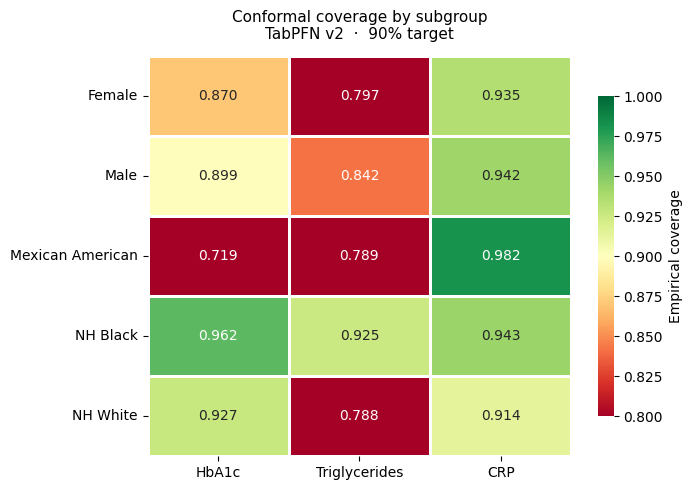

Saved: fig2_subgroup_coverage.png


In [ ]:
subgroup_rows = []

for oname, ocol in outcomes.items():
    r = all_results[oname].get("TabPFN v2")
    if r is None: continue

    y_all   = df_model[f"log_{ocol}"].values.astype(np.float32)
    y_te    = y_all[idx_test]
    covered = (y_te >= r["lower"]) & (y_te <= r["upper"])

    # Use df directly — same index as df_model, original string labels
    sex_orig = df["RIAGENDR"].values[idx_test]
    eth_orig = df["RIDRETH1"].values[idx_test]

    print(f"\n{oname}  (overall coverage: {covered.mean():.3f})")

    # Sex — string values
    for sl in ["Male", "Female"]:
        mask = sex_orig == sl
        if mask.sum() > 10:
            c = covered[mask].mean()
            subgroup_rows.append(dict(outcome=oname, group=sl,
                                      n=int(mask.sum()), coverage=round(c,3)))
            print(f"  {sl:<25} n={mask.sum():>4}  cov={c:.3f}")

    # Ethnicity — string values
    eth_labels = {
        "Mexican American":                    "Mexican American",
        "Other Hispanic":                       "Other Hispanic",
        "Non-Hispanic White":                   "NH White",
        "Non-Hispanic Black":                   "NH Black",
        "Other Race - Including Multi-Racial":  "Other",
    }
    for orig_label, short_label in eth_labels.items():
        mask = eth_orig == orig_label
        if mask.sum() > 10:
            c = covered[mask].mean()
            subgroup_rows.append(dict(outcome=oname, group=short_label,
                                      n=int(mask.sum()), coverage=round(c,3)))
            print(f"  {short_label:<25} n={mask.sum():>4}  cov={c:.3f}")

subgroup_df = pd.DataFrame(subgroup_rows)
print("\n", subgroup_df.to_string())

# Save CSV
subgroup_df.to_csv(
    "/content/drive/MyDrive/nhanes_results/subgroup_coverage.csv", index=False)
print("\nSaved: subgroup_coverage.csv")

# Plot heatmap
import matplotlib.pyplot as plt
import seaborn as sns

pivot = subgroup_df.pivot_table(
    index="group", columns="outcome", values="coverage")
pivot = pivot[["HbA1c", "Triglycerides", "CRP"]]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".3f",
            cmap="RdYlGn", vmin=0.80, vmax=1.0, center=0.90,
            linewidths=0.8, linecolor="white",
            cbar_kws={"label": "Empirical coverage", "shrink": 0.8},
            ax=ax)
ax.set_title("Conformal coverage by subgroup\nTabPFN v2  ·  90% target",
             fontsize=11, pad=12)
ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/nhanes_results/fig2_subgroup_coverage.png",
    dpi=200, bbox_inches="tight")
plt.show()
print("Saved: fig2_subgroup_coverage.png")

In [ ]:
desc = {
    "Age (years)":           "RIDAGEYR",
    "BMI (kg/m²)":           "BMXBMI",
    "HbA1c (%)":             "LBXGH",
    "Triglycerides (mg/dL)": "LBXTR",
    "CRP (mg/dL)":           "LBXCRP",
    "TAC (counts/day)":      "TAC",
    "MVPA (min/day)":        "MVPA",
    "Sedentary (min/day)":   "ST",
    "Energy (kcal/day)":     "DR1TKCAL",
}

print(f"{'Variable':<28} {'Mean':>8} {'SD':>8} {'Median':>8}")
print("-"*55)
for label, col in desc.items():
    if col in df_model.columns:
        v = df_model[col].dropna()
        print(f"{label:<28} {v.mean():>8.1f} {v.std():>8.1f} {v.median():>8.1f}")

print(f"\nN = {len(df_model)}")
print(f"\nSex:")
print(df["RIAGENDR"].value_counts(normalize=True).mul(100).round(1))
print(f"\nRace/ethnicity:")
print(df["RIDRETH1"].value_counts(normalize=True).mul(100).round(1))

Variable                         Mean       SD   Median
-------------------------------------------------------
Age (years)                      52.7     18.6     53.0
BMI (kg/m²)                      28.3      5.9     27.5
HbA1c (%)                         5.6      0.9      5.4
Triglycerides (mg/dL)           153.3    146.7    123.0
CRP (mg/dL)                       0.5      1.0      0.2
TAC (counts/day)             251293.4 139938.5 226809.1
MVPA (min/day)                   20.6     22.6     13.1
Sedentary (min/day)            1086.7    115.6   1093.0
Energy (kcal/day)              2149.0    931.9   1990.5

N = 1381

Sex:
RIAGENDR
Female    50.6
Male      49.4
Name: proportion, dtype: float64

Race/ethnicity:
RIDRETH1
Non-Hispanic White                     57.1
Mexican American                       20.8
Non-Hispanic Black                     15.9
Other Race - Including Multi-Racial     4.2
Other Hispanic                          2.0
Name: proportion, dtype: float64


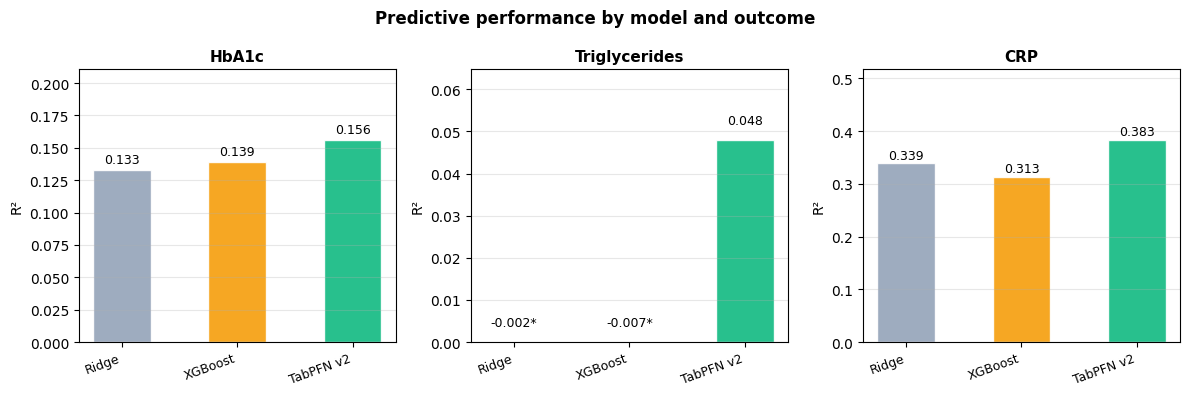

Saved: fig1_r2_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Predictive performance by model and outcome",
             fontsize=12, fontweight="bold")

COLORS = {"Ridge": "#94a3b8", "XGBoost": "#f59e0b", "TabPFN v2": "#10b981"}
MODEL_ORDER = ["Ridge", "XGBoost", "TabPFN v2"]

for ax, (oname, _) in zip(axes, outcomes.items()):
    names, vals = [], []
    for m in MODEL_ORDER:
        r = all_results[oname].get(m)
        if r:
            names.append(m)
            vals.append(max(r["r2"], 0))  # clip negative to 0 for display

    bars = ax.bar(names, vals,
                  color=[COLORS[m] for m in names],
                  alpha=0.9, edgecolor="white", width=0.5)

    ax.set_title(oname, fontsize=11, fontweight="bold")
    ax.set_ylabel("R²")
    ax.set_ylim(0, max(vals) * 1.35 if max(vals) > 0 else 0.1)
    ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    for bar, v, orig_v in zip(bars, vals,
                               [max(all_results[oname][m]["r2"], -99)
                                for m in names]):
        label = f"{orig_v:.3f}" if orig_v >= 0 else f"{orig_v:.3f}*"
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                label, ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/nhanes_results/fig1_r2_comparison.png",
    dpi=200, bbox_inches="tight")
plt.show()
print("Saved: fig1_r2_comparison.png")